# Required Libraries

In [ ]:
from PIL import Image, ImageOps         # For Image Handling
import numpy as np                      # NumPy
import scipy as sp                      # SciPy
import scipy.sparse.linalg              # Various Linear Algebra Tools
from scipy.fftpack import dct, idct     # For Image Blurring
import matplotlib.pyplot as plt         # For Plotting
import matplotlib.cm as cm              # ColorMaps for Plotting

# Importing the Image

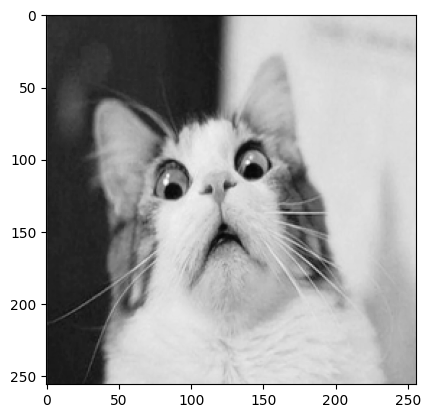

In [ ]:
# Load the image, Resize it, Grayscale it, and convert it to an array
img = Image.open('cat.jpg').resize((256, 256))
X_ref = np.asarray(ImageOps.grayscale(img)).astype('float32')

# Show image
plt.imshow(X_ref, cmap=cm.Greys_r, vmin=0, vmax=255)

# Blurring the Image

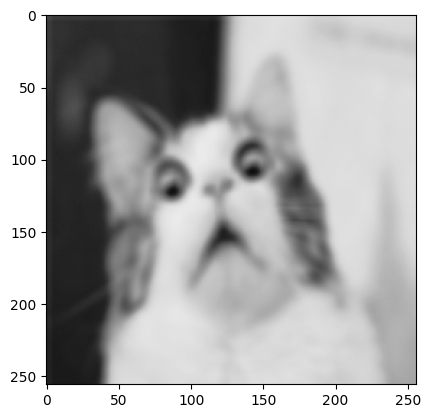

In [ ]:
# Black Box, Not Important how it works
def blackbox():
    s = 4
    size_filter = size = 9
    PSF = np.array([[np.exp(-0.5*((i-4)/s)**2- 0.5*((j-4)/s)**2)
                    for j in range(size)] for i in range(size)])
    PSF /= np.sum(PSF)
    def dctshift(PSF, center):
        m, n = PSF.shape
        i, j = center
        l = min(i, m-i-1, j, n-j-1)
        PP = PSF[i-l:i+l+1, j-l:j+l+1]
        Z1 = np.diag(np.ones(l+1), k=l )
        Z2 = np.diag(np.ones(l) , k=l+1)
        PP = Z1 @ PP @ Z1.T + Z1 @ PP @ Z2.T + Z2 @ PP @ Z1.T + \
             Z2 @ PP @ Z2.T
        Ps = np.zeros_like(PSF)
        Ps[0:2*l+1, 0:2*l+1] = PP
        return Ps
    dct2 = lambda a: dct(dct(a.T, norm='ortho').T, norm='ortho')
    idct2 = lambda a: idct(idct(a.T,norm='ortho').T,norm='ortho')
    Pbig = np.zeros_like(X_ref)
    Pbig[0:size_filter , 0:size_filter] = PSF
    e1 = np.zeros_like(X_ref)
    e1[0][0] = 1
    S = np.divide( dct2(dctshift(Pbig, (4,4))), dct2(e1) )
    R = lambda X, S_matrix=S: idct2( np.multiply(S_matrix, dct2(X)) )
    return R

# Retrieve blurring and adjoint of blurring operators
R = blackbox()

# Blur Image and add noise
np.random.seed(10)
n = np.random.normal(0, 0.5, size=X_ref.shape)
X_blur = R(X_ref) + n

# Show blurry image
plt.imshow(X_blur, cmap=cm.Greys_r, vmin=0, vmax=255)

# Discrete Gradient

In [ ]:
# The Discrete Gradient Linear Operator
# grad: R^{256x256}-> R^{2x256x256}
def grad(X):
    G = np.zeros_like([X, X])
    G[0, :, :-1] = X[:, 1:]- X[:, :-1] # Horizontal Direction
    G[1, :-1, :] = X[1:, :]- X[:-1, :] # Vertical Direction
    return G

# The Adjoint of the Discrete Gradient Linear Operator
# grad_T: R^{2x256x256}-> R^{256x256}
def grad_T(Y):
    G_T = np.zeros_like(Y[0])

    G_T[:, :-1] += Y[0, :, :-1] # Corresponds to c[0]
    G_T[:-1, :] += Y[1, :-1, :] # Corresponds to c[1]
    G_T[:, 1:]-= Y[0, :, :-1] # Corresponds to c[0]
    G_T[1:, :]-= Y[1, :-1, :] # Corresponds to c[1]

    return G_T

# Primal-Dual Method

Stop at 1


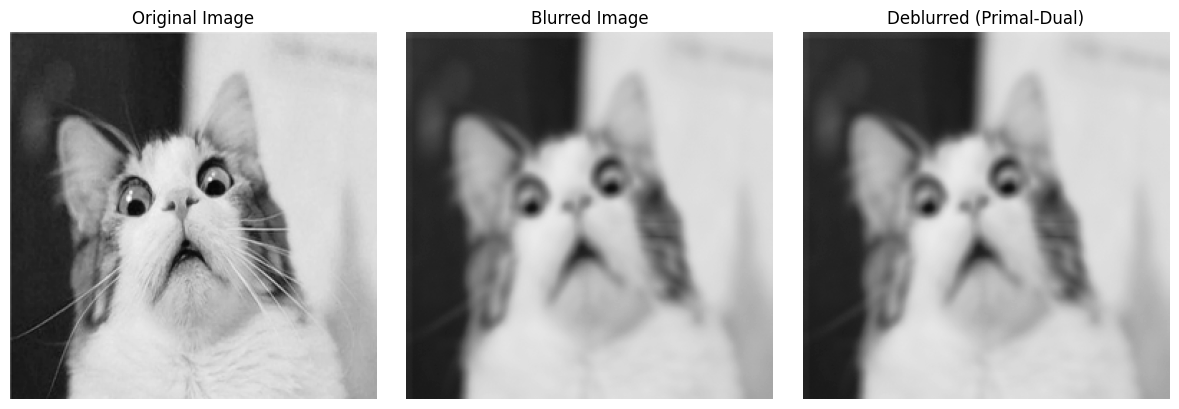

In [ ]:
def primal_dual(X_ref, X_blur, R, grad, grad_T, lambda_, tau, sigma, num_iterations):
    # Proximal operator for f
    def prox_f_star(x, tau, lambda_, X_blur):
        return ((tau *lambda_ / (tau*lambda_ + 1)) * (x - (1/tau)* X_blur))

    def prox_f(x, tau, lambda_, X_blur):
        return x - tau * prox_f_star(x/tau, tau, lambda_, X_blur)

    # Proximal operator for g*
    def prox_g_star(y):
        return np.clip(y, -1, 1)

    # Initialize primal and dual variables
    X = X_blur.copy()
    Y = grad(X)


    # Primal-Dual Iteration
    for k in range(num_iterations):
        # Update primal variable X
        X_prev = X
        X = prox_f(X - tau * grad_T(Y), tau, lambda_, X_blur)

        # Update dual variable Y
        Y_prev = Y
        Y = prox_g_star(Y_prev + sigma * grad(2 * X - X_prev))

        if np.linalg.norm(X_ref-X) > np.linalg.norm(X_ref-X_prev) :
            print(f"Stop at {k}")
            break
        #if k % 100 == 0:  # Display every 10 iterations
            #print(f"Iteration {k}: Change in X = {np.linalg.norm(X - X_prev)}")

    return X, num_iterations

deblurred_image, _ = primal_dual(X_ref, X_blur, R, grad, grad_T, lambda_=1000, tau=0.001, sigma=0.001, num_iterations=4000)
# Plotting the results
plt.figure(figsize=(16, 4))  # Adjust the figure size for better visibility

# Original Image
plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st subplot
plt.imshow(X_ref, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

# Blurred Image
plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd subplot
plt.imshow(X_blur, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Blurred Image")
plt.axis('off')

# Deblurred Image
plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd subplot
plt.imshow(deblurred_image, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Deblurred (Primal-Dual)")
plt.axis('off')
plt.tight_layout()
plt.show()

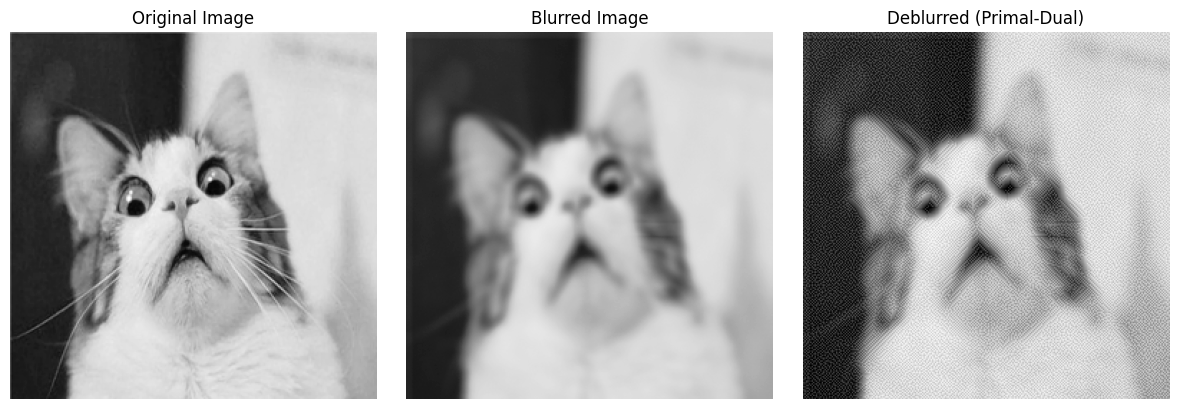

In [ ]:
def primal_dual(X_blur, R, grad, grad_T, lambda_, tau, sigma, num_iterations):
    # Proximal operator for f
    def prox_f_star(x, tau, lambda_, X_blur):
        return ((tau *lambda_ / (tau*lambda_ + 1)) * (x - (1/tau)* X_blur))

    def prox_f(x, tau, lambda_, X_blur):
        return x - tau * prox_f_star(x/tau, tau, lambda_, X_blur)

    # Proximal operator for g*
    def prox_g_star(y):
        return np.clip(y, -1, 1)

    # Initialize primal and dual variables
    X = X_blur.copy()
    Y = grad(X)


    # Primal-Dual Iteration
    for k in range(num_iterations):
        # Update primal variable X
        X_prev = X
        X = prox_f(X - tau * grad_T(Y), tau, lambda_, X_blur)

        # Update dual variable Y
        Y_prev = Y
        Y = prox_g_star(Y_prev + sigma * grad(2 * X - X_prev))

        #if k % 100 == 0:  # Display every 10 iterations
            #print(f"Iteration {k}: Change in X = {np.linalg.norm(X - X_prev)}")

    return X

X_deblur= primal_dual(X_blur, R, grad, grad_T, lambda_=0.15, tau=1/(2*np.sqrt(2)), sigma=1/(2*np.sqrt(2)), num_iterations=10000)
# Plotting the results
plt.figure(figsize=(16, 4))  # Adjust the figure size for better visibility

# Original Image
plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st subplot
plt.imshow(X_ref, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

# Blurred Image
plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd subplot
plt.imshow(X_blur, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Blurred Image")
plt.axis('off')

# Deblurred Image
plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd subplot
plt.imshow(X_deblur, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Deblurred (Primal-Dual)")
plt.axis('off')
plt.tight_layout()
plt.show()

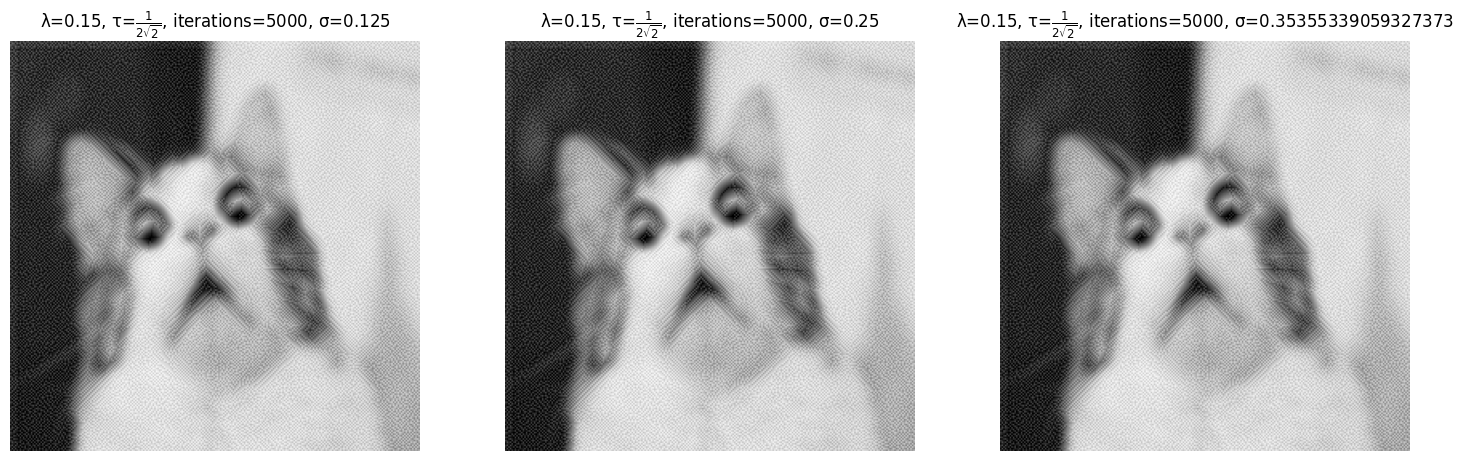

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Parameters to test
sigmas = [1/8, 1/4, 1/(2*np.sqrt(2))]
lambda_= 0.15

# Creating the figure to hold subplots (len(lambdas) rows, len(taus) columns)
fig, axes = plt.subplots(1, len(sigmas), figsize=(15, 5))

for j, sigma in enumerate(sigmas):
            #print(f"Testing lambda={lam}, tau={tau}, sigma={sigma}")
            X_deblur = primal_dual(X_blur, R, grad, grad_T, lambda_= 0.15, tau=1/(2*np.sqrt(2)), sigma=sigma, num_iterations=5*10**3)

            # Select the appropriate subplot
            ax = axes[j]  # Use the i-th row and j-th column for this subplot
            ax.imshow(X_deblur, cmap=cm.Greys_r, vmin=0, vmax=255)
            ax.set_title(f"λ={0.15}, τ="r'$\frac{1}{2\sqrt{2}}$'f", iterations={5000}, σ={sigma}")
            ax.axis('off')

# Adjust layout for better spacing
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


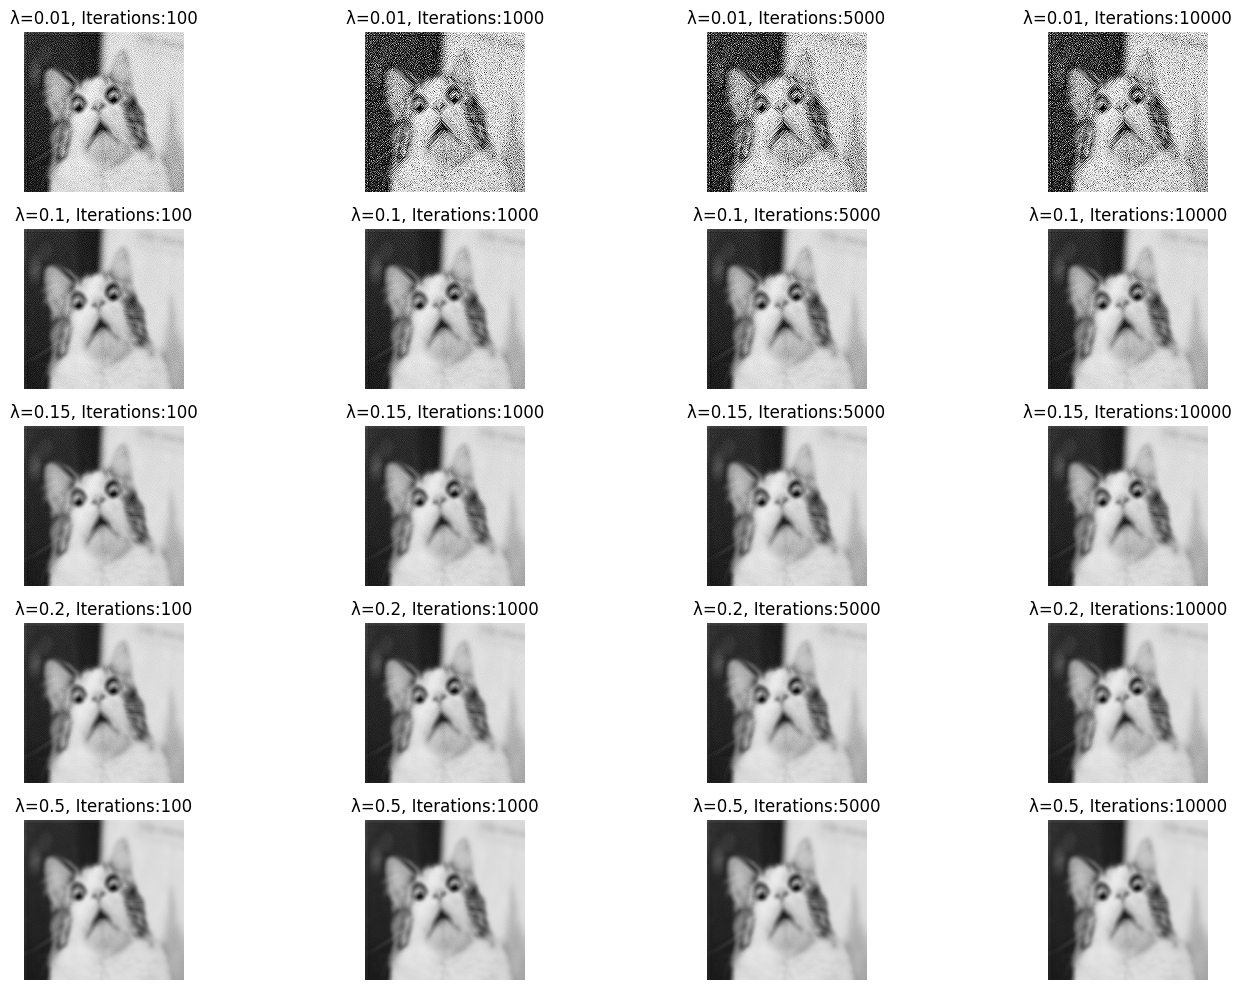

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Parameters to test
lambdas = [0.01,0.1, 0.15, 0.2,0.5]
maxits=[10**2, 10**3, 5*10**3, 10**4]
# Creating the figure to hold subplots (len(lambdas) rows, len(taus) columns)
fig, axes = plt.subplots(len(lambdas), len(maxits), figsize=(15, 10))

for i, lam in enumerate(lambdas):
    for j, maxit in enumerate(maxits):
            #print(f"Testing lambda={lam}, tau={tau}, sigma={sigma}")
            X_deblur = primal_dual(X_blur, R, grad, grad_T, lambda_=lam, tau=1/(2*np.sqrt(2)), sigma=1/(2*np.sqrt(2)), num_iterations=maxit)

            # Select the appropriate subplot
            ax = axes[i, j]  # Use the i-th row and j-th column for this subplot
            ax.imshow(X_deblur, cmap=cm.Greys_r, vmin=0, vmax=255)
            ax.set_title(f"λ={lam}, Iterations:{maxit}")
            ax.axis('off')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


**Final Plots**

In [ ]:
from scipy.sparse.linalg import cg, LinearOperator




# ADMM function
def admm_deblur(X_blur, R, grad, grad_T, lambda_, rho, num_iter):
  # Define operator A
    def A_operator(X, R, rho, grad, grad_T):
      RTR_term = lambda_ * R(R(X))
      grad_term = rho * grad_T(grad(X))
      A_X = RTR_term + grad_term
      return A_X.ravel()

    def soft_thresholding(Y, tau):
      return np.sign(Y) * np.maximum(np.abs(Y) - tau, 0)
    # Initialization
    X = X_blur
    Y = grad(X)
    Z = Y

    for k in range(num_iter):
        #print(k)
        # Solve for X^{k+1} using Conjugate Gradient
        b = lambda_ * R(X_blur) + grad_T((rho * Y) - Z)
        # Pass necessary arguments to A_operator
        A = LinearOperator((np.prod(X.shape), np.prod(X.shape)), matvec=lambda x: A_operator(x.reshape(X.shape), R, rho, grad, grad_T))

        X_solution, info = cg(A, b.ravel(), maxiter=10000)

        if info != 0:
            print(f"CG did not converge, info: {info}")

        X = X_solution.reshape(X.shape)

        # Update Y^{k+1} (Soft-thresholding)
        Y = soft_thresholding(grad(X) + Z/rho, 1 / rho)

        # Update Z^{k+1}
        Z += rho * (grad(X) - Y)

    return X


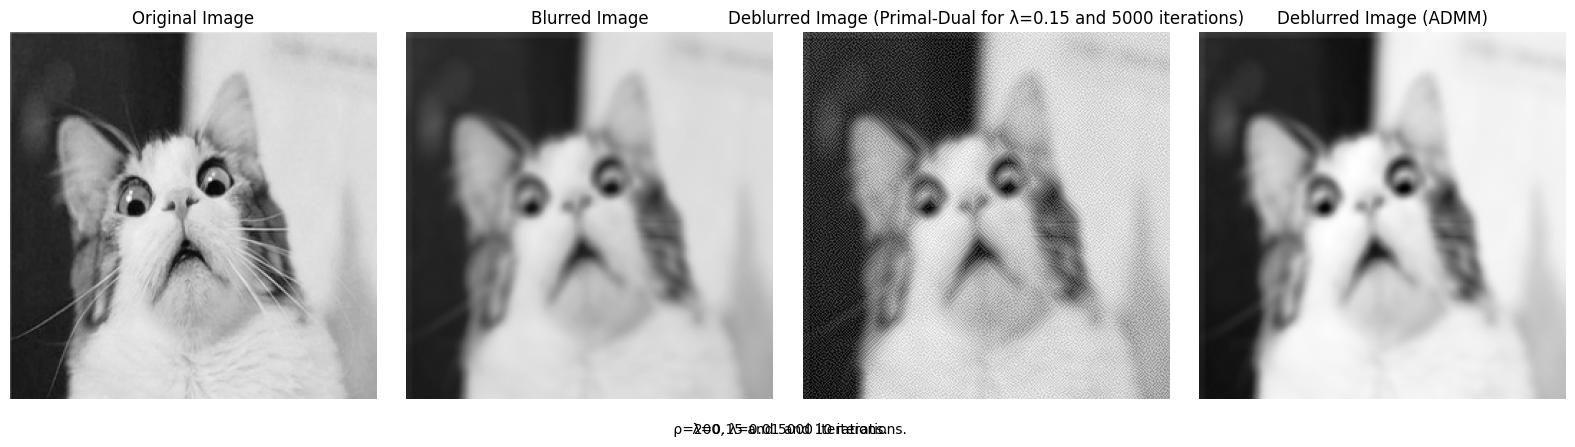

In [ ]:
X_deblur_ADMM= admm_deblur(X_blur, R, grad, grad_T, lambda_=0.01, rho=200, num_iter=10)
X_deblur_PD= primal_dual(X_blur, R, grad, grad_T, lambda_=0.15, tau=1/(2*np.sqrt(2)), sigma=1/(2*np.sqrt(2)), num_iterations=10000)

# Plotting the results
plt.figure(figsize=(16, 4))  # Adjust the figure size for better visibility

# Original Image
plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st subplot
plt.imshow(X_ref, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

# Blurred Image
plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd subplot
plt.imshow(X_blur, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Blurred Image")
plt.axis('off')

# Deblurred Image(PD)
plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd subplot
plt.imshow(X_deblur_PD, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Deblurred Image (Primal-Dual for λ=0.15 and 5000 iterations)")
plt.figtext(0.5, -0.05, ' λ=0.15 and 5000 iterations.', wrap=True, horizontalalignment='center', fontsize=10)
plt.axis('off')

# Deblurred Image (ADMM)
plt.subplot(1, 4, 4)  # 1 row, 4 columns, 3rd subplot
plt.imshow(deblurred_image, cmap=cm.Greys_r)
plt.title("Deblurred Image (ADMM)")
plt.figtext(0.5, -0.05, ' ρ=200, λ=0.01 and 10 iterations.', wrap=True, horizontalalignment='center', fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

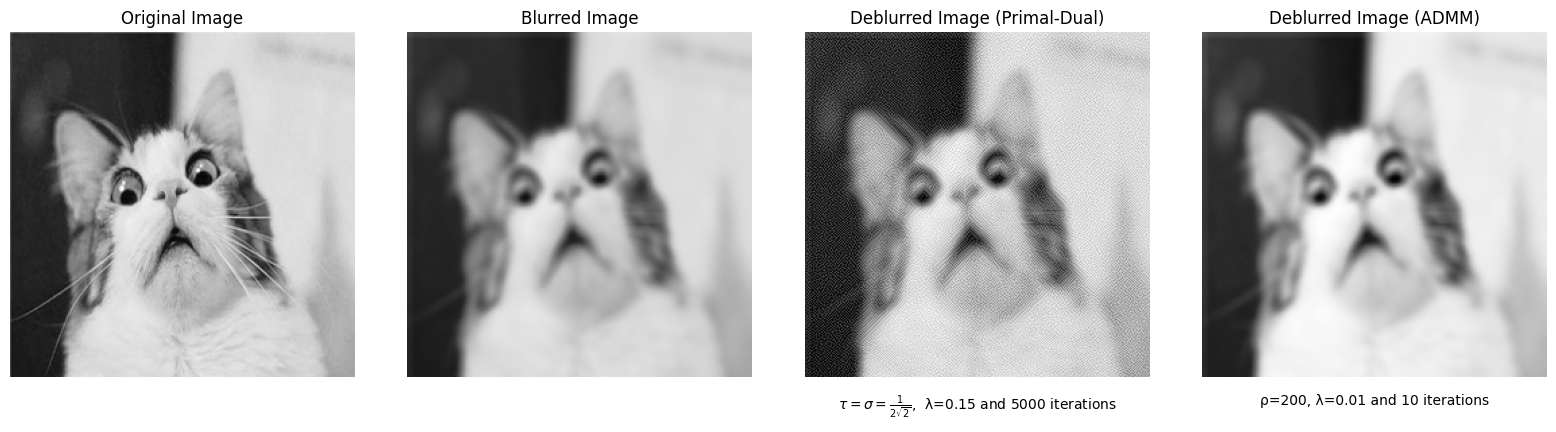

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Plotting the results
plt.figure(figsize=(16, 4))  # Adjust the figure size for better visibility

# Original Image
plt.subplot(1, 4, 1)
plt.imshow(X_ref, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

# Blurred Image
plt.subplot(1, 4, 2)
plt.imshow(X_blur, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Blurred Image")
plt.axis('off')

# Deblurred Image (Primal-Dual)
plt.subplot(1, 4, 3)
plt.imshow(X_deblur_PD, cmap=cm.Greys_r, vmin=0, vmax=255)
plt.title("Deblurred Image (Primal-Dual)")
plt.axis('off')
plt.text(0.5, -0.05, r'$τ=σ = \frac{1}{2\sqrt{2}}$,  λ=0.15 and 5000 iterations', ha='center', va='top', fontsize=10, transform=plt.gca().transAxes)

# Deblurred Image (ADMM)
plt.subplot(1, 4, 4)
plt.imshow(X_deblur_ADMM, cmap=cm.Greys_r)
plt.title("Deblurred Image (ADMM)")
plt.axis('off')
plt.text(0.5, -0.05, 'ρ=200, λ=0.01 and 10 iterations', ha='center', va='top', fontsize=10, transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()


